# Полиномиальные модели

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
# Правильная ссылка на raw-содержимое файла
url = "https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML3.1%20polynomial%20features/data/gen_regression.csv"

# Загружаем данные
data = pd.read_csv(url)

In [7]:
data.head()

,Unnamed: 0,x,y
0,0,96.597780,97761.592016
1,1,48.002892,27613.989207
2,2,47.939756,29410.187753
3,3,47.809026,15789.597531
4,4,69.784427,20953.383453


In [8]:
X = data.x
y = data.y

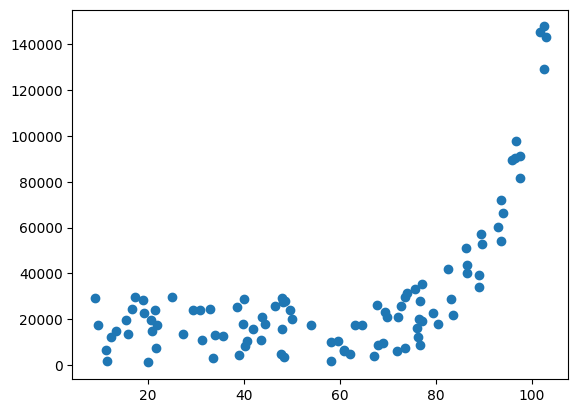

In [9]:
plt.scatter(X, y)

In [14]:
print(X.shape)

if isinstance(X, pd.Series):
    X = X.to_frame()

(100, 1)


In [15]:
from sklearn.linear_model import LinearRegression
linear = LinearRegression().fit(X, y)

In [16]:
X = pd.DataFrame(X)

/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


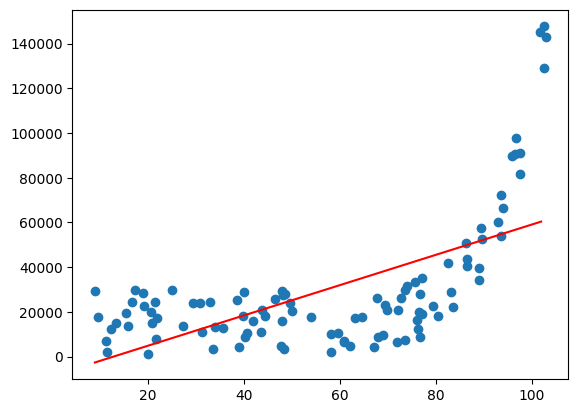

In [17]:
xx = np.arange(X.x.min(axis=0), X.x.max(axis=0))
yy = linear.predict(pd.DataFrame(xx))

plt.scatter(X.x, y)
plt.plot(xx, yy, c='r')

In [18]:
linear.score(X, y)

0.37467360318911636

In [19]:
from sklearn.preprocessing import PolynomialFeatures

In [20]:
transformation = PolynomialFeatures(degree=2)

In [21]:
transformation.fit(X)

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [22]:
X_2 = transformation.transform(X)

In [23]:
X_2.shape
X_2[:5]

array([[1.00000000e+00, 9.65977805e+01, 9.33113119e+03],
       [1.00000000e+00, 4.80028921e+01, 2.30427765e+03],
       [1.00000000e+00, 4.79397558e+01, 2.29822018e+03],
       [1.00000000e+00, 4.78090258e+01, 2.28570295e+03],
       [1.00000000e+00, 6.97844271e+01, 4.86986627e+03]])

In [24]:
poly_2d = LinearRegression().fit(X_2, y)

In [25]:
xx_2d = transformation.transform(pd.DataFrame(xx))

/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


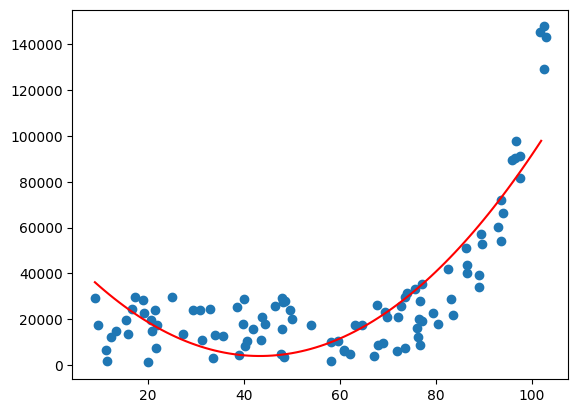

In [26]:
yy_2d = poly_2d.predict(xx_2d)
plt.scatter(X.x, y)
plt.plot(xx, yy_2d, c='r')

In [27]:
poly_2d.score(X_2, y)

0.7359753787024843

In [28]:
data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/gen_classification.csv",
                   index_col=0)

In [29]:
y = data.y
X = data.drop(["y"], axis=1)

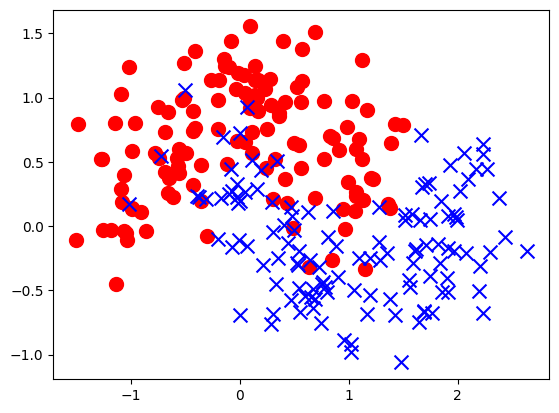

In [30]:
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
logistic = LogisticRegression().fit(X, y)

/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


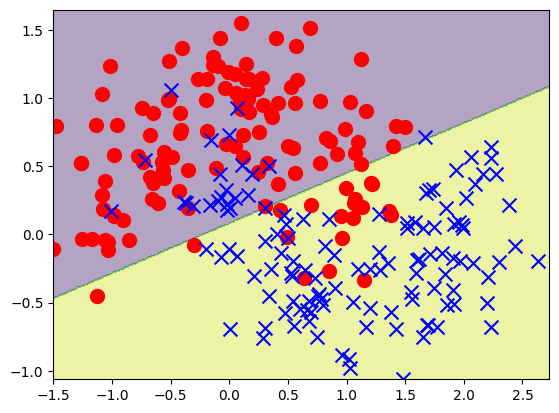

In [35]:
xx, yy = np.meshgrid(
    np.arange(X.min().iloc[0], X.max().iloc[0] + 0.1, 0.01),
    np.arange(X.min().iloc[1], X.max().iloc[1] + 0.1, 0.01))

XX = np.array(list(zip(xx.ravel(), yy.ravel()))).reshape((-1, 2))

Z = logistic.predict(XX).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

In [36]:
logistic.score(X, y)

0.832

In [37]:
class_transform = PolynomialFeatures(degree=3, include_bias=False)
X_3 = class_transform.fit_transform(X)

In [38]:
X_3.shape

(250, 9)

In [39]:
class_3 = LogisticRegression().fit(X_3, y)

/Users/cancer/Технология решений задач ML/myenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


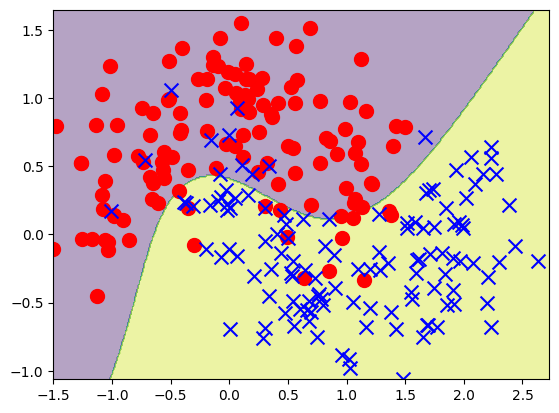

In [40]:
Z = class_3.predict(class_transform.transform(XX)).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

In [41]:
class_3.score(X_3, y)

0.9

In [42]:
data_kc_prices = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/kc_house_data.csv")
data_kc_prices.shape

(21613, 21)

In [43]:
data_kc_prices.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [44]:
y_kc_prices = data_kc_prices.price
X_kc_prices = data_kc_prices.drop(["id", "date", "price"], axis=1)

In [45]:
X_kc_prices.shape, y_kc_prices.shape

((21613, 18), (21613,))

In [46]:
reg_kc_multiple = LinearRegression().fit(X_kc_prices, y_kc_prices)
reg_kc_multiple.score(X_kc_prices, y_kc_prices)

0.6997471890109157

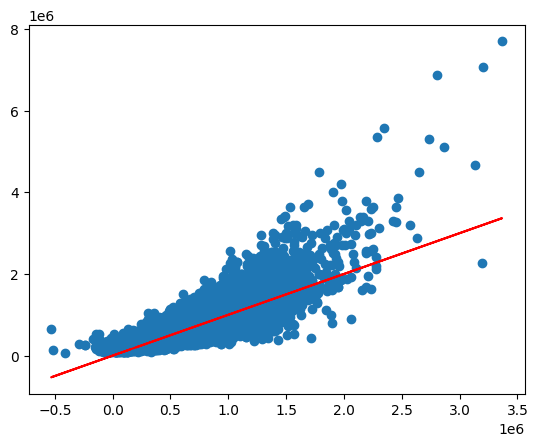

In [47]:
y_pred_kc_prices = reg_kc_multiple.predict(X_kc_prices)
plt.scatter(y_pred_kc_prices, y_kc_prices)
plt.plot(y_pred_kc_prices, y_pred_kc_prices, c='r')

In [48]:
X_3_kc_prices = (poly_features_kc_prices := PolynomialFeatures(degree=3)).fit_transform(X_kc_prices)

In [49]:
X_3_kc_prices.shape

(21613, 1330)

In [50]:
reg_poly2_kc = LinearRegression().fit(X_3_kc_prices, y_kc_prices)
reg_poly2_kc.score(X_3_kc_prices, y_kc_prices)

0.8326020796592413

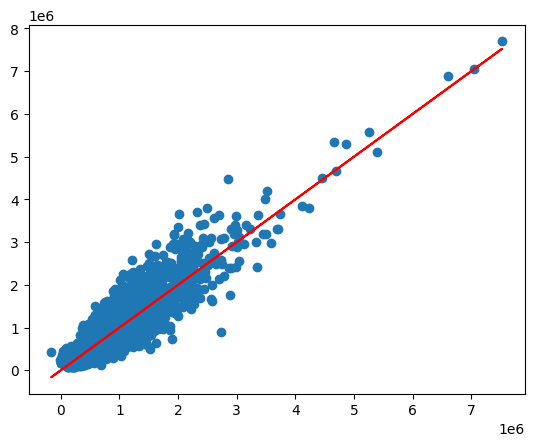

In [51]:
y_pred_kc_prices = reg_poly2_kc.predict(X_3_kc_prices)
plt.scatter(y_pred_kc_prices, y_kc_prices)
plt.plot(y_pred_kc_prices, y_pred_kc_prices, c='r')

# Задачи для самостоятельного решения

## Задания 1–4: Сводная таблица точности и времени обучения для всех датасетов

In [52]:
import time
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


def benchmark_poly(X, y, degrees, task='regression'):
    """Обучает модели разных степеней, возвращает DataFrame с R²/accuracy и временем."""
    rows = []
    for deg in degrees:
        t0 = time.perf_counter()
        if task == 'regression':
            m = make_pipeline(PolynomialFeatures(deg), LinearRegression())
        else:
            m = make_pipeline(PolynomialFeatures(deg, include_bias=False),
                              LogisticRegression(max_iter=1000))
        m.fit(X, y)
        elapsed = (time.perf_counter() - t0) * 1000
        score = m.score(X, y)
        rows.append({"degree": deg, "score": round(score, 4), "time_ms": round(elapsed, 2)})
    return pd.DataFrame(rows).set_index("degree")

In [53]:
# --- gen_regression (задание 2) ---
# Пересоздаём чистые X/y из исходных данных
url_reg = "https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML3.1%20polynomial%20features/data/gen_regression.csv"
data_reg = pd.read_csv(url_reg)
X_reg = data_reg[['x']]
y_reg = data_reg['y']

degrees_reg = [1, 2, 5, 10, 100]
table_reg = benchmark_poly(X_reg, y_reg, degrees_reg, task='regression')
print("=== gen_regression (R²) ===")
print(table_reg)

=== gen_regression (R²) ===
         score  time_ms
degree                 
1       0.3747     4.70
2       0.7360     1.09
5       0.9217     0.97
10      0.9222     1.23
100     0.7925     1.56


In [54]:
# --- gen_classification (задание 3) ---
data_cls = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/gen_classification.csv",
                       index_col=0)
X_cls = data_cls.drop('y', axis=1)
y_cls = data_cls['y']

degrees_cls = [1, 2, 3, 5, 10]
table_cls = benchmark_poly(X_cls, y_cls, degrees_cls, task='classification')
print("=== gen_classification (accuracy) ===")
print(table_cls)

=== gen_classification (accuracy) ===
        score  time_ms
degree                
1       0.832     3.25
2       0.836     2.12
3       0.900     2.43
5       0.916     3.22
10      0.924     5.24


In [55]:
# --- King County (задание 3) — степени 1, 2, 3 (deg=5+ слишком много признаков) ---
data_kc = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/kc_house_data.csv")
X_kc = data_kc.drop(["id", "date", "price"], axis=1)
y_kc = data_kc['price']

degrees_kc = [1, 2, 3]
table_kc = benchmark_poly(X_kc, y_kc, degrees_kc, task='regression')
print("=== King County (R²) ===")
print(table_kc)

=== King County (R²) ===
         score  time_ms
degree                 
1       0.6997     9.39
2       0.8084   145.56
3       0.8326  2361.25


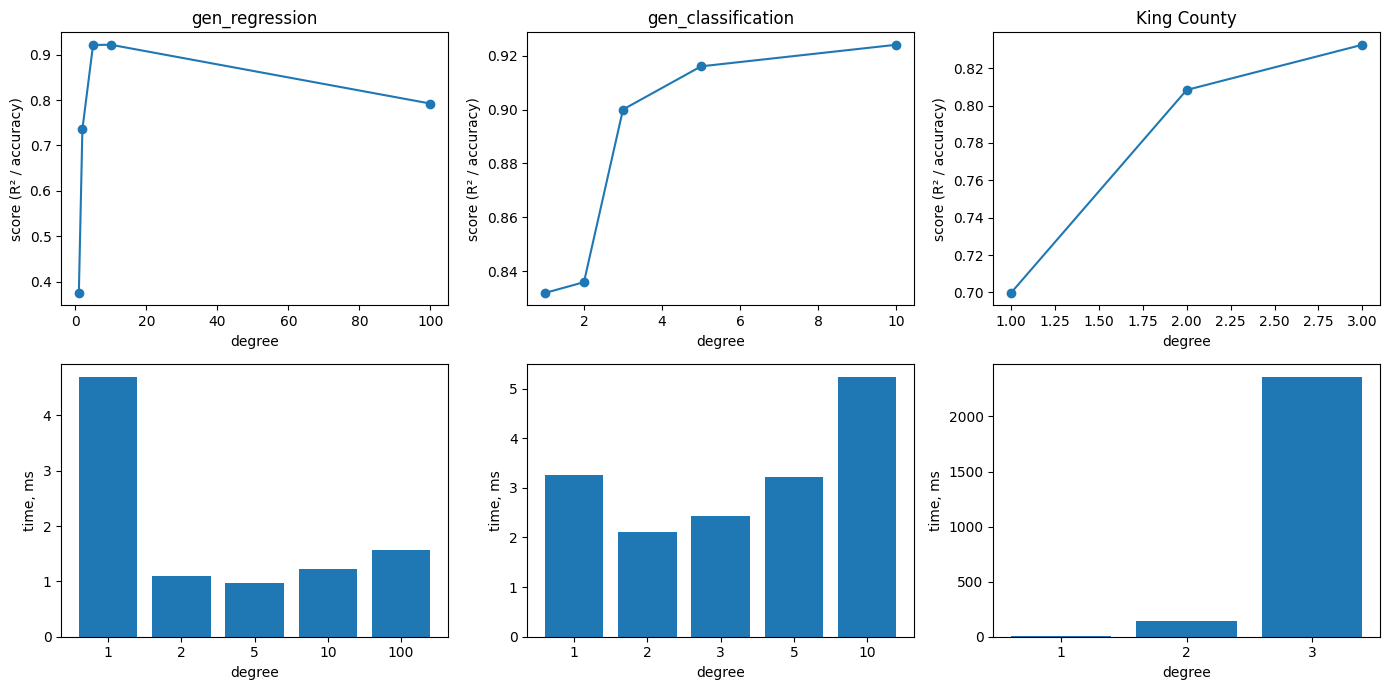

In [56]:
# Сводный график: score и time_ms по всем трём датасетам (задание 4)
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
titles = ["gen_regression", "gen_classification", "King County"]
tables = [table_reg, table_cls, table_kc]

for col, (title, tbl) in enumerate(zip(titles, tables)):
    axes[0, col].plot(tbl.index, tbl['score'], marker='o')
    axes[0, col].set_title(title)
    axes[0, col].set_xlabel("degree")
    axes[0, col].set_ylabel("score (R² / accuracy)")

    axes[1, col].bar(tbl.index.astype(str), tbl['time_ms'])
    axes[1, col].set_xlabel("degree")
    axes[1, col].set_ylabel("time, ms")

plt.tight_layout()
plt.show()

# Вывод: высокие степени полинома (≥5) дают прирост точности на простых данных,
# но на King County (18 признаков) степень 3 → 1330 признаков, время растёт экспоненциально.

## Задание 5: Коэффициенты линейной модели King County — важность признаков

      feature   coefficient
        grade 112712.655853
          lat  83517.098428
  sqft_living  81812.507110
     yr_built -76963.112236
   sqft_above  76305.519976
   waterfront  50434.938435
         view  40514.994738
     bedrooms -33264.325458
    bathrooms  31687.074375
      zipcode -31161.669278
         long -30239.346185
sqft_basement  27005.679556
    condition  17169.880475
sqft_living15  14859.899556
   sqft_lot15 -10447.480092
 yr_renovated   7958.119456
     sqft_lot   5326.466291
       floors   3612.199207


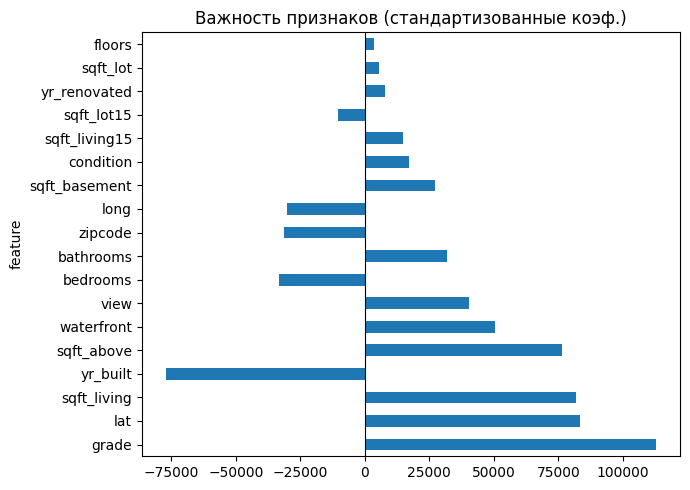

In [57]:
from sklearn.preprocessing import StandardScaler

# Масштабируем признаки, чтобы коэффициенты были сопоставимы
scaler = StandardScaler()
X_kc_scaled = scaler.fit_transform(X_kc)

lin_scaled = LinearRegression().fit(X_kc_scaled, y_kc)

coef_df = pd.DataFrame({
    'feature': X_kc.columns,
    'coefficient': lin_scaled.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df.to_string(index=False))

coef_df.set_index('feature')['coefficient'].plot(kind='barh', figsize=(7, 5))
plt.axvline(0, color='k', linewidth=0.8)
plt.title("Важность признаков (стандартизованные коэф.)")
plt.tight_layout()
plt.show()
# Вывод: признаки с наибольшим |коэффициентом| после стандартизации
# (sqft_living, grade, lat и пр.) сильнее всего влияют на цену.

## Задание 6: Интерпретация полиномиальной модели

Топ-20 наиболее важных полиномиальных признаков:
               feature    coefficient
          yr_renovated -811564.474394
        yr_renovated^2  182120.774915
                 grade   88735.436182
                   lat   77732.937474
                  long  -59416.664963
           sqft_living   53913.568643
               zipcode  -50652.243044
            sqft_above   50643.565215
                 lat^2  -49511.191754
         sqft_living15   40286.625398
yr_built sqft_living15  -32925.028579
              lat long  -31208.201714
         yr_built long   30238.454991
    sqft_above zipcode  -25486.109772
             condition   25123.286664
             grade lat   23679.773503
       sqft_above long  -23295.104833
      sqft_living long  -23042.568126
            grade long  -20840.375705
              sqft_lot   20735.729447


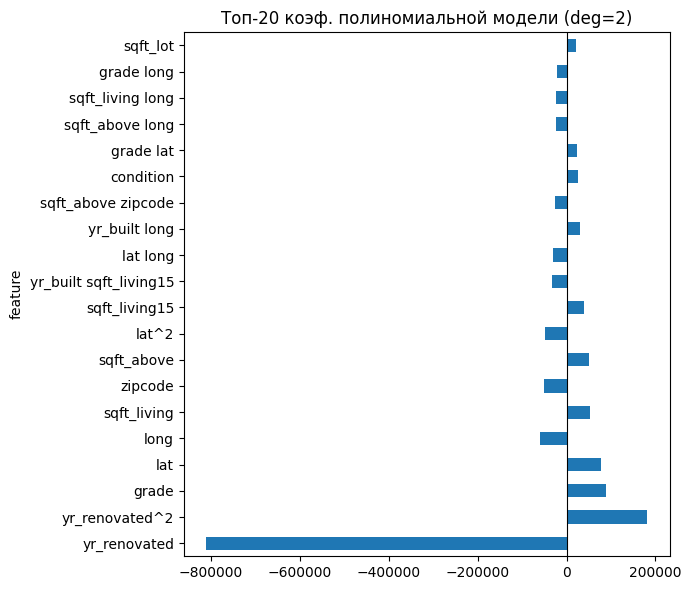

In [58]:
poly2 = PolynomialFeatures(degree=2)
X_kc_poly = poly2.fit_transform(X_kc_scaled)  # масштабированные → полином

poly_model = LinearRegression().fit(X_kc_poly, y_kc)

# Имена полиномиальных признаков
feature_names = poly2.get_feature_names_out(X_kc.columns)

poly_coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': poly_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

# Топ-20 по абсолютному значению
print("Топ-20 наиболее важных полиномиальных признаков:")
print(poly_coef_df.head(20).to_string(index=False))

poly_coef_df.head(20).set_index('feature')['coefficient'].plot(kind='barh', figsize=(7, 6))
plt.axvline(0, color='k', linewidth=0.8)
plt.title("Топ-20 коэф. полиномиальной модели (deg=2)")
plt.tight_layout()
plt.show()
# Вывод: взаимодействия типа sqft_living*grade означают, что большой дом
# высокого класса даёт дополнительный мультипликативный эффект на цену.